# Orthomosaic tiling for ML (RGB)

This notebook:
1. Selects a pseudo orthomosaic tif
2. Computes coverage area and saves/displays a quicklook PNG
3. Tiles the valid (non-black / non-nodata) region into fixed-size tiles with overlap
4. Skips mostly-empty tiles and writes per-tile JSON metadata


In [1]:
# 0 — Imports

from pathlib import Path
import json
import random
import shutil

import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.transform import Affine
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform

# For JPG/PNG reading
from PIL import Image

# Optional (for display)
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

In [2]:
# 1 — Select case folder and pseudo-ortho image

from pathlib import Path

PSEUDO_ROOT = Path("./output/pseudo_ortho")   # contains case folders
OUT_ROOT    = Path("./output/tiles_out_pseudo_ortho")


def pick_case(root: Path) -> Path:
    cases = sorted([p for p in root.iterdir() if p.is_dir() and not p.name.startswith('.')])

    if not cases:
        raise FileNotFoundError(f"No case folders found in {root.resolve()}")

    print("\nAvailable cases:")
    for i, c in enumerate(cases, 1):
        print(f"{i:2d}) {c.name}")

    choice = int(input("\nSelect a case number: ").strip())
    if choice < 1 or choice > len(cases):
        raise ValueError("Invalid selection.")

    return cases[choice - 1]


def pick_image(folder: Path) -> Path:
    imgs = sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in (".tif", ".tiff")
    ])

    if not imgs:
        raise FileNotFoundError(f"No GeoTIFF (.tif/.tiff) found in {folder.resolve()}")

    print("\nAvailable pseudo-ortho GeoTIFFs:")
    for i, p in enumerate(imgs, 1):
        print(f"{i:2d}) {p.name}")

    choice = int(input("\nSelect image number: ").strip())
    if choice < 1 or choice > len(imgs):
        raise ValueError("Invalid selection.")

    return imgs[choice - 1]


# ---- workflow ----

CASE_FOLDER = pick_case(PSEUDO_ROOT)
PSEUDO_PATH = pick_image(CASE_FOLDER)

OUT_DIR = OUT_ROOT / CASE_FOLDER.name

print("\nSelected case:", CASE_FOLDER.name)
print("Selected image:", PSEUDO_PATH.name)
print("OUT_DIR:", OUT_DIR)


Available cases:
 1) a10_segment1
 2) a58_segment2



Select a case number:  2



Available pseudo-ortho GeoTIFFs:
 1) pseudo_ortho_rotated.tif



Select image number:  1



Selected case: a58_segment2
Selected image: pseudo_ortho_rotated.tif
OUT_DIR: output/tiles_out_pseudo_ortho/a58_segment2


In [3]:
def reset_output_folder(out_dir: Path):
    if out_dir.exists():
        shutil.rmtree(out_dir)
    (out_dir / "images").mkdir(parents=True, exist_ok=True)
    (out_dir / "meta").mkdir(parents=True, exist_ok=True)
    print(f"Output folder reset: {out_dir}")

def read_tile_rgb(src, window):
    """
    Read a window from GeoTIFF and return HWC uint8 RGB.
    """
    data = src.read([1,2,3], window=window, boundless=True, fill_value=0)  # CHW
    data = np.transpose(data, (1,2,0))  # HWC

    if data.dtype != np.uint8:
        data = np.clip(data, 0, 255).astype(np.uint8)

    return data

def compute_valid_bbox_img(img_hwc: np.ndarray, black_thr_u8: int = 5) -> tuple[int,int,int,int]:
    """
    Return (x0, y0, x1, y1) bbox in pixel coords covering 'valid' pixels.
    Valid = not near-black.
    """
    # valid mask: any channel > threshold
    valid = (img_hwc[..., 0] > black_thr_u8) | (img_hwc[..., 1] > black_thr_u8) | (img_hwc[..., 2] > black_thr_u8)
    ys, xs = np.where(valid)
    if len(xs) == 0 or len(ys) == 0:
        # nothing valid -> whole image (or raise)
        return (0, 0, img_hwc.shape[1], img_hwc.shape[0])
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    return (x0, y0, x1, y1)

def invalid_fraction_img(tile_hwc: np.ndarray, black_thr_u8: int = 5) -> float:
    """Fraction of pixels that are near-black (treated as invalid)."""
    invalid = (tile_hwc[..., 0] <= black_thr_u8) & (tile_hwc[..., 1] <= black_thr_u8) & (tile_hwc[..., 2] <= black_thr_u8)
    return float(invalid.mean())

def save_png_hwc(tile_hwc: np.ndarray, out_path: Path):
    Image.fromarray(tile_hwc).save(out_path)

In [4]:
# Settings (reuse yours)
TILE_SIZE  = 512
OVERLAP    = 128
SKIP_INVALID_FRACTION = 0.70
BLACK_THRESH_U8 = 5

from rasterio.windows import Window
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform

def tile_pseudo_ortho_irregular_geotiff_to_png(
    image_path: Path,
    out_dir: Path,
    tile_size: int,
    overlap: int,
    skip_invalid_fraction: float = 0.70,
):
    step = tile_size - overlap
    if step <= 0:
        raise ValueError("OVERLAP must be smaller than TILE_SIZE.")

    images_dir = out_dir / "images"
    meta_dir   = out_dir / "meta"
    images_dir.mkdir(parents=True, exist_ok=True)
    meta_dir.mkdir(parents=True, exist_ok=True)

    tiles_index = []
    saved = skipped = total = 0

    with rasterio.open(image_path) as src:
        H, W = src.height, src.width
        crs = src.crs
        tfm = src.transform

        print(f"Source: {image_path.name}")
        print(f"Image size: {W}x{H}")
        print(f"CRS: {crs}")
        print(f"Tiling step: {step} px  (tile={tile_size}, overlap={overlap})")

        # ---- Determine valid bbox by scanning a coarse grid (fast) ----
        # We avoid reading the full GeoTIFF into memory.
        # We'll sample tiles on a coarse step to estimate the valid bbox (non-black).
        sample_step = max(tile_size, step * 4)
        valid_lefts, valid_tops = [], []

        for top in range(0, H, sample_step):
            for left in range(0, W, sample_step):
                win = Window(
                    left,
                    top,
                    min(tile_size, W - left),
                    min(tile_size, H - top)
                )
                
                tile = read_tile_rgb(src, win)  # HWC uint8
                inv = invalid_fraction_img(tile, black_thr_u8=BLACK_THRESH_U8)
                if inv < 0.98:  # "some data exists"
                    valid_lefts.append(left)
                    valid_tops.append(top)

        if valid_lefts and valid_tops:
            x0 = max(0, min(valid_lefts) - tile_size)
            y0 = max(0, min(valid_tops) - tile_size)
            x1 = min(W, max(valid_lefts) + tile_size * 2)
            y1 = min(H, max(valid_tops) + tile_size * 2)
        else:
            # fallback: whole image
            x0, y0, x1, y1 = 0, 0, W, H

        print(f"Estimated valid bbox (pixels): x[{x0},{x1}) y[{y0},{y1})")

        # ---- Main tiling loop ----
        for top in range(y0, y1, step):
            for left in range(x0, x1, step):
                total += 1

                # fixed-size only
                if (left + tile_size > W) or (top + tile_size > H):
                    skipped += 1
                    continue

                win = Window(left, top, tile_size, tile_size)
                tile = read_tile_rgb(src, win)  # HWC uint8

                inv = invalid_fraction_img(tile, black_thr_u8=BLACK_THRESH_U8)
                if inv >= skip_invalid_fraction:
                    skipped += 1
                    continue

                tile_id  = f"x{left}_y{top}_s{tile_size}"
                out_path = images_dir / f"{tile_id}.png"
                save_png_hwc(tile, out_path)

                # Geospatial metadata for this tile
                tile_tfm = window_transform(win, tfm)
                b = window_bounds(win, tfm)  # (left, bottom, right, top)

                meta = {
                    "tile_id": tile_id,
                    "image_file": out_path.name,
                    "source_image": image_path.name,

                    "left_px": int(left),
                    "top_px": int(top),
                    "tile_size_px": int(tile_size),
                    "overlap_px": int(overlap),
                    "step_px": int(step),
                    "invalid_fraction": float(inv),

                    # ✅ keep real-world coordinates even though tile is PNG
                    "crs": str(crs),
                    "transform": [tile_tfm.a, tile_tfm.b, tile_tfm.c,
                                  tile_tfm.d, tile_tfm.e, tile_tfm.f],
                    "bounds": {"left": b[0], "bottom": b[1], "right": b[2], "top": b[3]},
                }

                (meta_dir / f"{tile_id}.json").write_text(json.dumps(meta, indent=2))
                tiles_index.append(meta)
                saved += 1

    index_path = out_dir / "tiles_index.json"
    index_path.write_text(json.dumps(tiles_index, indent=2))

    print("\nDone.")
    print(f"Total windows checked: {total}")
    print(f"Saved tiles: {saved}")
    print(f"Skipped tiles: {skipped}")
    print("Index file:", index_path)

    return tiles_index

# Run
reset_output_folder(OUT_DIR)
tiles_index = tile_pseudo_ortho_irregular_geotiff_to_png(
    image_path=PSEUDO_PATH,
    out_dir=OUT_DIR,
    tile_size=TILE_SIZE,
    overlap=OVERLAP,
    skip_invalid_fraction=SKIP_INVALID_FRACTION,
)

Output folder reset: output/tiles_out_pseudo_ortho/a58_segment2
Source: pseudo_ortho_rotated.tif
Image size: 23852x18896
CRS: EPSG:32610
Tiling step: 384 px  (tile=512, overlap=128)
Estimated valid bbox (pixels): x[1024,22528) y[0,18896)

Done.
Total windows checked: 2800
Saved tiles: 1415
Skipped tiles: 1385
Index file: output/tiles_out_pseudo_ortho/a58_segment2/tiles_index.json


In [5]:
# Quick PNG preview of the GeoTIFF

PREVIEW_SCALE = 0.15   # 15% size (adjust if needed)

preview_path = PSEUDO_PATH.with_suffix(".preview.png")

with rasterio.open(PSEUDO_PATH) as src:
    # read RGB bands
    data = src.read([1,2,3])  # CHW
    
    # convert to HWC
    img = np.transpose(data, (1,2,0))

    # downscale
    H, W = img.shape[:2]
    new_w = int(W * PREVIEW_SCALE)
    new_h = int(H * PREVIEW_SCALE)

    preview = Image.fromarray(img).resize((new_w, new_h), Image.Resampling.BILINEAR)

    preview.save(preview_path)

print("Preview saved:", preview_path)

Preview saved: output/pseudo_ortho/a58_segment2/pseudo_ortho_rotated.preview.png


Number of tiles: 1415


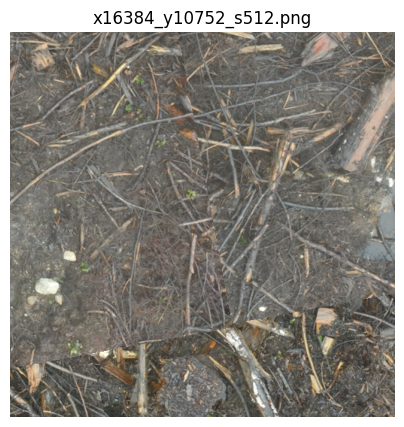

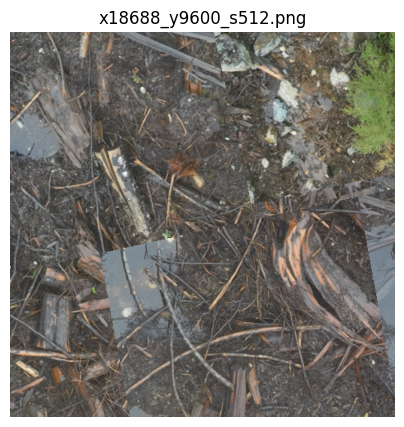

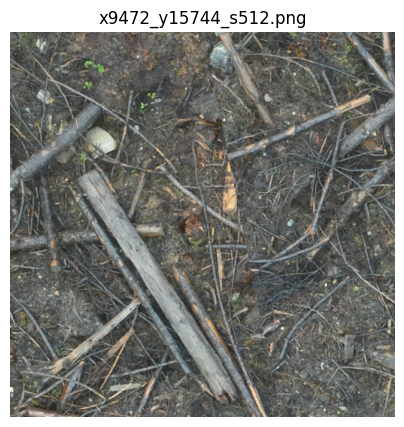

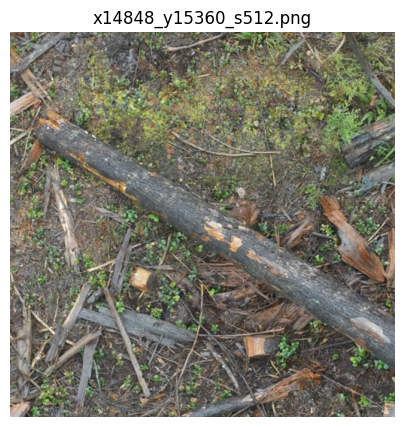

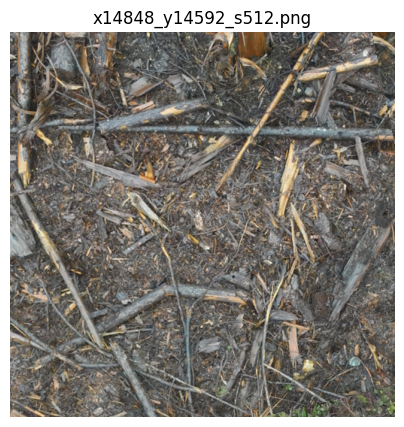

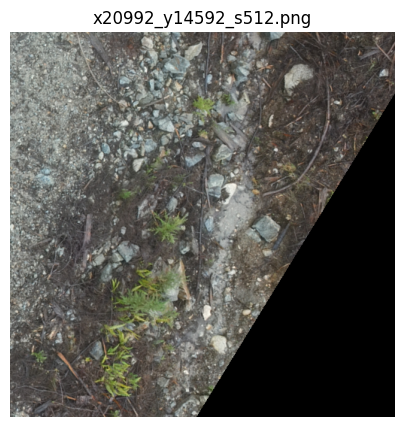

In [6]:
# 6 (optional) — Preview a few saved tiles

import random
from PIL import Image

tiles = list((OUT_DIR / "images").glob("*.png"))

print("Number of tiles:", len(tiles))

if plt is None:
    print("matplotlib not available; skipping preview.")

elif not tiles:
    print("No tiles saved.")

else:
    sample = random.sample(tiles, k=min(6, len(tiles)))

    for p in sample:
        img = np.array(Image.open(p))

        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.title(p.name)
        plt.axis("off")
        plt.show()